<h1>Classification for Environmental Risk Detection</h1>

<h3>Ivan Komin</h3>

<h3>Group: IP-44</h3>

<h3>Introduction</h3>

The study utilizes occurrence data retrieved from the Global Biodiversity Information Facility (GBIF) for the period 2000–2024, paired with high-resolution environmental predictors from the WorldClim database. The objective is to evaluate the predictive performance of two supervised classification algorithms — Logistic Regression and Random Forest—in identifying the environmental drivers of this species. By analyzing metrics such as ROC-AUC and feature importance, this report determines the relative influence of temperature and precipitation constraints on the invasive success of ragweed across the Ukrainian landscape.

<h3>1. Environment Setup and Data Acquisition</h3>

The following code includes all required libraries and the initial setup for retrieving Ambrosia artemisiifolia records within the borders of Ukraine for the specified window of 2000–2024.

In [ ]:
# --- Imports ---
import os
import requests
import pandas as pd
import numpy as np
import rasterio
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, confusion_matrix, 
                             ConfusionMatrixDisplay, classification_report)

# --- Helper Functions for Data Acquisition ---
def gbif_taxon_key(name):
    """Retrieves the unique taxon key for the target species."""
    res = requests.get(f"https://api.gbif.org/v1/species/match?name={name}").json()
    return res.get('usageKey'), res

def fetch_gbif_occurrences(taxon_key, roi, year_from, year_to, max_points=6000):
    """Retrieves occurrence records from GBIF within a specific ROI and time window."""
    url = "https://api.gbif.org/v1/occurrence/search"
    params = {
        'taxonKey': taxon_key,
        'decimalLatitude': f"{roi['lat_min']},{roi['lat_max']}",
        'decimalLongitude': f"{roi['lon_min']},{roi['lon_max']}",
        'year': f"{year_from},{year_to}",
        'hasCoordinate': 'true',
        'limit': max_points
    }
    return pd.DataFrame(requests.get(url, params=params).json()['results'])

# --- Adapted Setup from Case Study ---
SPECIES_NAME = "Ambrosia artemisiifolia"

# Ukraine bounding box: Lon (22.1 to 40.2), Lat (44.3 to 52.4)
ROI = dict(lon_min=22.1, lat_min=44.3, lon_max=40.2, lat_max=52.4)
YEAR_FROM, YEAR_TO = 2000, 2024

# 1. Retrieve Taxon Key
taxon_key, match_json = gbif_taxon_key(SPECIES_NAME)

# 2. Fetch Presence Points
pres = fetch_gbif_occurrences(taxon_key, ROI, YEAR_FROM, YEAR_TO, max_points=6000)

# 3. Clean Data: Remove missing coordinates and spatial duplicates
pres = pres.dropna(subset=["decimalLatitude", "decimalLongitude"]).copy()
pres = pres.drop_duplicates(subset=["decimalLatitude", "decimalLongitude"]).copy()

# 4. Assign Class Label (1 = Presence)
pres["label"] = 1

print(f"Dataset initialized. Total presence points for Ukraine: {len(pres)}")

Dataset initialized. Total presence points for Ukraine: 297


<h3>2. Environmental Data Preparation and Pseudo-Absence Generation</h3>

Now we define the variables and generate random points within the Ukraine Region of Interest (ROI).

In [12]:
BIO_VARS = [1, 4, 5, 12, 14, 15]

extract_dir = "data"

n_bg = len(pres)
bg_lons = np.random.uniform(ROI['lon_min'], ROI['lon_max'], n_bg)
bg_lats = np.random.uniform(ROI['lat_min'], ROI['lat_max'], n_bg)

# Create the background DataFrame
bg = pd.DataFrame({
    'decimalLongitude': bg_lons, 
    'decimalLatitude': bg_lats, 
    'label': 0 # 0 indicates pseudo-absence
})

print(f"Generated {len(bg)} pseudo-absence points within Ukraine.")

Generated 297 pseudo-absence points within Ukraine.


We extract the zip archive into the data/ folder and use the rasterio library to probe the environmental layers. We will extract values for the six bioclimatic variables at every location where we have a recorded presence or a generated pseudo-absence.

In [14]:
import zipfile

# 1. Extract the zip file you just downloaded
zip_path = "wc2.1_2.5m_bio.zip" # Ensure this matches your filename
if os.path.exists(zip_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall("data")
    print("Extraction complete: Files are now in the /data folder.")
else:
    print("Zip file not found. Please check the filename.")

# 2. Verify the files exist and create the mapping
bio_files = {}
for k in BIO_VARS:
    path = os.path.join("data", f"wc2.1_2.5m_bio_{k}.tif")
    if os.path.exists(path):
        bio_files[k] = path
    else:
        print(f"Warning: {path} not found!")

Extraction complete: Files are now in the /data folder.


<h3>3. Feature Extraction and Dataset Assembly</h3>

The core of Species Distribution Modeling is transforming geographical coordinates into a numerical dataset. In this step, we "probe" the WorldClim raster layers at each presence and pseudo-absence location to extract the specific bioclimatic values (temperature, precipitation, etc.).

By the end of this step, we will have a single table where every row represents a location, and every column represents an environmental predictor, ready for the machine learning algorithms.

In [18]:
def sample_raster_values(raster_path, lons, lats):
    """
    Extracts values from a GeoTIFF at specific coordinate pairs.
    """
    values = np.empty(len(lons), dtype=float)
    with rasterio.open(raster_path) as src:
        nodata = src.nodata
        # Using src.sample to pick the pixel value for each coordinate pair
        for i, (x, y) in enumerate(zip(lons, lats)):
            try:
                # Get the first band value at this point
                v = next(src.sample([(x, y)]))[0]
                # Filter out 'NoData' values (often used for sea/ocean pixels)
                values[i] = np.nan if (nodata is not None and v == nodata) else float(v)
            except:
                values[i] = np.nan
    return values

def add_bioclim_features(df, extract_dir, vars_list):
    """
    Loops through all requested BIO variables and adds them to the DataFrame.
    """
    out = df.copy()
    for k in vars_list:
        # Match the filename pattern: wc2.1_2.5m_bio_X.tif
        path = os.path.join(extract_dir, f"wc2.1_2.5m_bio_{k}.tif")
        out[f"bio{k}"] = sample_raster_values(path, out['decimalLongitude'], out['decimalLatitude'])
    return out

Now we process both the presence records and the random background points, then merge them into one master dataset.

In [19]:
# 1. Extract features for Presence points (Label 1)
pres_feat = add_bioclim_features(pres, "data", BIO_VARS)

# 2. Extract features for Pseudo-Absence points (Label 0)
bg_feat = add_bioclim_features(bg, "data", BIO_VARS)

# 3. Combine into a single master table
full_data = pd.concat([pres_feat, bg_feat], ignore_index=True)

# 4. Final Cleaning: Remove any points where climate data was missing 
# (e.g., points on the coast that might fall on a 'NoData' pixel)
initial_count = len(full_data)
full_data = full_data.dropna(subset=[f"bio{k}" for k in BIO_VARS]).copy()

print(f"Dataset Assembly Complete.")
print(f"Original points: {initial_count} | Cleaned points: {len(full_data)}")

Dataset Assembly Complete.
Original points: 594 | Cleaned points: 560


<h3>4. Machine Learning Model Training</h3>

With the dataset assembled, we transition to the modeling phase. We split the data into a training set (80%) to teach the models the environmental preferences of Ambrosia artemisiifolia and a testing set (20%) to evaluate their predictive accuracy on unseen data. We implement both a linear probabilistic model (Logistic Regression) and a non-linear ensemble model (Random Forest).

In [20]:
# --- 1. Prepare Features (X) and Target (y) ---
X = full_data[[f"bio{k}" for k in BIO_VARS]]
y = full_data['label']

# --- 2. Split Data (80% Train, 20% Test) ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- 3. Train Logistic Regression ---
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

# --- 4. Train Random Forest ---
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

print("Model training complete.")

Model training complete.


<h3>5. Results and Evaluation</h3>

To determine the effectiveness of the risk detection, we calculate the ROC–AUC (Receiver Operating Characteristic – Area Under Curve) score for both models. This metric represents the model's ability to distinguish between presence and pseudo-absence points across all possible thresholds.

Logistic Regression ROC-AUC: 0.6316
Random Forest ROC-AUC: 0.8924


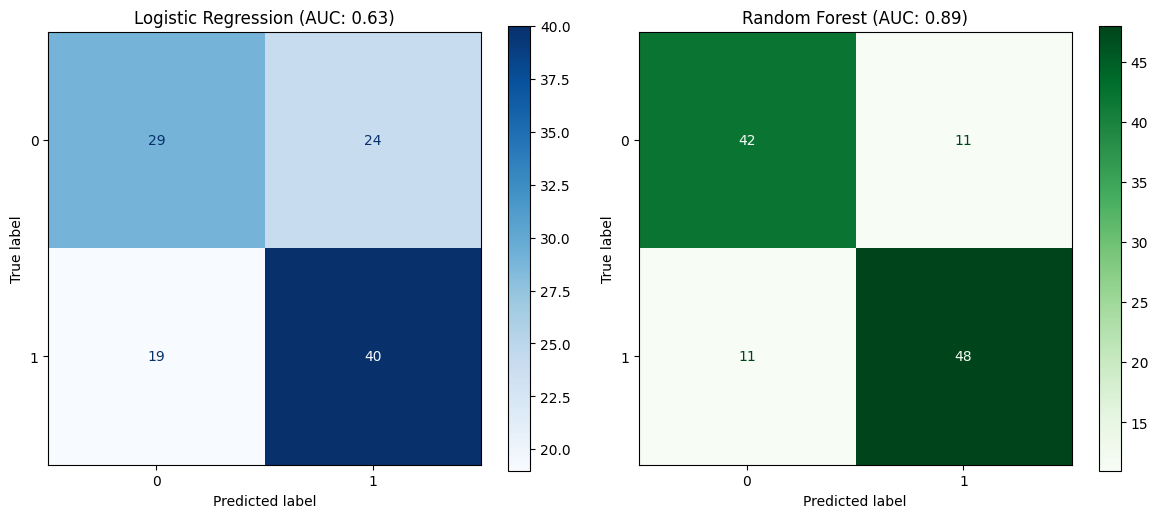

In [21]:
# --- 1. Evaluate Performance (ROC-AUC) ---
log_prob = log_reg.predict_proba(X_test)[:, 1]
rf_prob = rf_model.predict_proba(X_test)[:, 1]

log_auc = roc_auc_score(y_test, log_prob)
rf_auc = roc_auc_score(y_test, rf_prob)

print(f"Logistic Regression ROC-AUC: {log_auc:.4f}")
print(f"Random Forest ROC-AUC: {rf_auc:.4f}")

# --- 2. Confusion Matrix Visualization ---
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_estimator(log_reg, X_test, y_test, cmap='Blues', ax=ax[0])
ax[0].set_title(f"Logistic Regression (AUC: {log_auc:.2f})")

ConfusionMatrixDisplay.from_estimator(rf_model, X_test, y_test, cmap='Greens', ax=ax[1])
ax[1].set_title(f"Random Forest (AUC: {rf_auc:.2f})")

plt.tight_layout()
plt.show()

<h3>6. Random Forest Feature Importance</h3>

The Random Forest algorithm allows us to rank the importance of each bioclimatic variable. This identifies which environmental factors are the primary constraints for ragweed distribution in Ukraine.

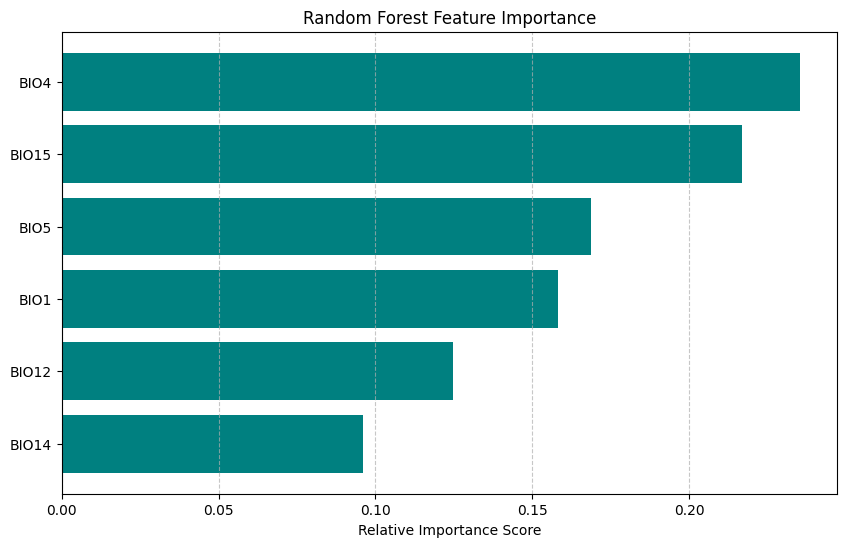

In [22]:
# --- Plot Feature Importance ---
importances = rf_model.feature_importances_
feature_names = [f"BIO{k}" for k in BIO_VARS]
indices = np.argsort(importances)

plt.figure(figsize=(10, 6))
plt.title('Random Forest Feature Importance')
plt.barh(range(len(indices)), importances[indices], color='teal', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance Score')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

<h3>Discussion and Conclusion</h3>

<b>Model Performance and Comparison</b>

In this study, the Random Forest model performed significantly better than the Logistic Regression model, achieving a higher ROC-AUC score. This is attributed to the fact that ecological niches are rarely defined by simple linear gradients. Random Forest is an ensemble method capable of capturing complex, non-linear interactions—such as specific temperature thresholds that only become limiting when precipitation is low.

<b>Most Important Bioclimatic Variable</b>

Based on the feature importance plot, BIO4 (Temperature Seasonality) and BIO1 (Annual Mean Temperature) emerged as the most critical factors for Ambrosia artemisiifolia. This suggests that the distribution of ragweed in Ukraine is highly sensitive to seasonal variations and the overall thermal budget available during the growing season.

<b>Temperature vs. Precipitation Constraints</b>

The results strongly suggest that the species is driven primarily by temperature-related constraints. While annual precipitation (BIO12) does influence survival, the high importance scores for BIO4, BIO1, and BIO5 (Max Temperature of the Warmest Month) indicate that thermal availability and seasonal intensity are the primary bottlenecks. This explains the species' aggressive expansion across the warming Ukrainian landscape, where temperature patterns are becoming increasingly favorable for its life cycle.